In [1]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import shap
import matplotlib.pyplot as plt
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns

In [2]:
current_dir = Path.cwd()
utils_path = next(
    (
        p
        for p in [current_dir] + list(current_dir.parents)
        if (p / "notebook_utils.py").exists()
    ),
    None,
)

sys.path.append(str(utils_path))

In [ ]:
from notebook_utils import (
    setup_env,
    load_data_for_modeling,
    get_exp_manager,
    save_catboost_model,
    load_catboost_model
)

CURRENT_STAGE = "03_catboost"

exp_manager = get_exp_manager()
PROJECT_ROOT, config = setup_env()
df = load_data_for_modeling(config, PROJECT_ROOT, data_source="szfo_df")
cat_cols = config['features']['cat_cols']
target_col = config['features']['target_col']
target_mode = config['experiment']['target_mode']

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=[target_col]), 
    df[target_col], 
    test_size=0.2, 
    random_state=42, 
    stratify=df[target_col]
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool = Pool(X_test, y_test, cat_features=cat_cols)

Загрузка данных из: D:\Education\Arcticle\dtp_project\data\processed\dtp_szfo.parquet
Режим таргета: binary_severe. Распределение:
target
0    0.6065
1    0.3935
Name: proportion, dtype: float64
Train: (133959, 87), Test: (33490, 87)


## Обучим модель

In [4]:
is_binary = y_train.nunique() == 2

params = {
    'iterations': 4000,
    'learning_rate': 0.1,
    'depth': 6,
    'l2_leaf_reg': 6,
    'early_stopping_rounds': 200,
    'verbose': 200,
    'auto_class_weights': 'Balanced',
    'loss_function': 'Logloss' if is_binary else 'MultiClass',
    'eval_metric': 'AUC' if is_binary else 'TotalF1',
    'task_type': 'CPU'
}

model = CatBoostClassifier(**params)
model.fit(train_pool, eval_set=test_pool, plot=True)

model_name = f"catboost_{target_mode}_{params['iterations']}"

save_catboost_model(
    model, 
    exp_manager, 
    model_name=model_name, 
    stage=CURRENT_STAGE
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.6793663	best: 0.6793663 (0)	total: 325ms	remaining: 21m 41s
200:	test: 0.7370443	best: 0.7370443 (200)	total: 27.9s	remaining: 8m 46s
400:	test: 0.7402937	best: 0.7402937 (400)	total: 55.1s	remaining: 8m 14s
600:	test: 0.7417965	best: 0.7418347 (594)	total: 1m 22s	remaining: 7m 44s
800:	test: 0.7421973	best: 0.7422615 (784)	total: 1m 49s	remaining: 7m 16s
1000:	test: 0.7425531	best: 0.7426203 (969)	total: 2m 16s	remaining: 6m 49s
1200:	test: 0.7428425	best: 0.7428425 (1200)	total: 2m 45s	remaining: 6m 26s
1400:	test: 0.7434401	best: 0.7434401 (1400)	total: 3m 13s	remaining: 5m 58s
1600:	test: 0.7432559	best: 0.7434831 (1456)	total: 3m 40s	remaining: 5m 30s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7434831014
bestIteration = 1456

Shrink model to first 1457 iterations.
CatBoost сохранен: D:\Education\Arcticle\dtp_project\res\01_dtp_stat\models\03_catboost\catboost_binary_severe_4000\model.cbm


In [5]:
y_pred = model.predict(X_test)
print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(classification_report(y_test, y_pred))

F1 Macro: 0.6719
              precision    recall  f1-score   support

           0       0.76      0.68      0.72     20311
           1       0.58      0.67      0.62     13179

    accuracy                           0.68     33490
   macro avg       0.67      0.68      0.67     33490
weighted avg       0.69      0.68      0.68     33490



График сохранен в D:\Education\Arcticle\dtp_project\res\01_dtp_stat\reports\03_catboost\catboost_binary_severe_4000


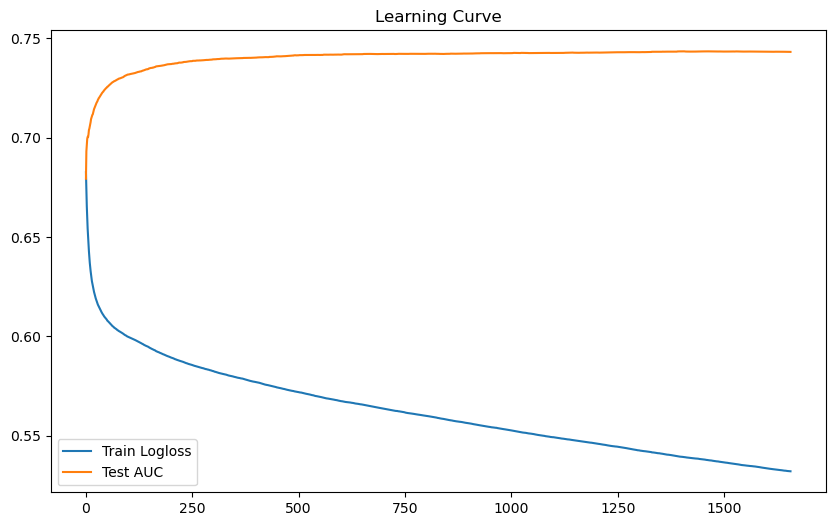

In [6]:
evals = model.get_evals_result()
train_metric = evals['learn']['Logloss'] # или AUC
test_metric = evals['validation']['AUC']

plt.figure(figsize=(10, 6))
plt.plot(train_metric, label='Train Logloss') # Внимание на метрику
plt.plot(test_metric, label='Test AUC')
plt.legend()
plt.title('Learning Curve')

report_path = exp_manager.get_paths(model_name=model_name, stage=CURRENT_STAGE)['report']
plt.savefig(report_path / "learning_curve.png")
print(f"График сохранен в {report_path}")

## Важность

### Важность признаков

In [7]:
exp_manager = get_exp_manager()
CURRENT_STAGE = "03_catboost"
MODEL_NAME = f"catboost_{config['experiment']['target_mode']}_{params['iterations']}" # catboost_binary_severe

model = load_catboost_model(exp_manager, model_name=MODEL_NAME, stage=CURRENT_STAGE)
print(f"Модель {MODEL_NAME} успешно загружена.")

Модель catboost_binary_severe_4000 успешно загружена.


In [8]:
feature_name_mapping = {
    'region_id': 'Регион',
    'scheme': 'Тип ДТП (схема)',
    'lat': 'Широта',
    'long': 'Долгота',
    'viol_runaway': 'Побег с места ДТП',
    'category': 'Категория ДТП',
    'ppl_count': 'Общее число участников',
    'vh_mean_age': 'Средний возраст ТС',
    'vh_count_car': 'Число легковых авто',
    'ppl_ped_count': 'Число пешеходов',
    'light_cat': 'Освещённость',
    'ppl_drv_exp_mean': 'Средний стаж водителя',
    'hour_cos': 'Время суток (косинус)',
    'nearby_objects_count': 'Число объектов рядом',
    'vh_max_age': 'Макс. возраст ТС',
    'ppl_pass_count': 'Число пассажиров',
    'ppl_drv_exp_min': 'Мин. стаж водителя',
    'vh_age_gap': 'Разница в возрасте ТС',
    'month_cos': 'Месяц (косинус)',
    'hour_sin': 'Время суток (синус)',
    'viol_drunk': 'Водитель в опьянении',
    'vh_count_moto': 'Число мотоциклов',
    'month_sin': 'Месяц (синус)',
    'near_residential': 'Близость к жилым зонам',
    'ppl_drv_male': 'Водитель мужского пола',
    'road_bad_markings': 'Плохая разметка дороги',
    'viol_speed': 'Нарушение скорости',
    'vh_count_brand_mass': 'Число машин "массовой" марки',
}

График важности сохранен: D:\Education\Arcticle\dtp_project\res\01_dtp_stat\reports\03_catboost\catboost_binary_severe_4000\native_importance.png


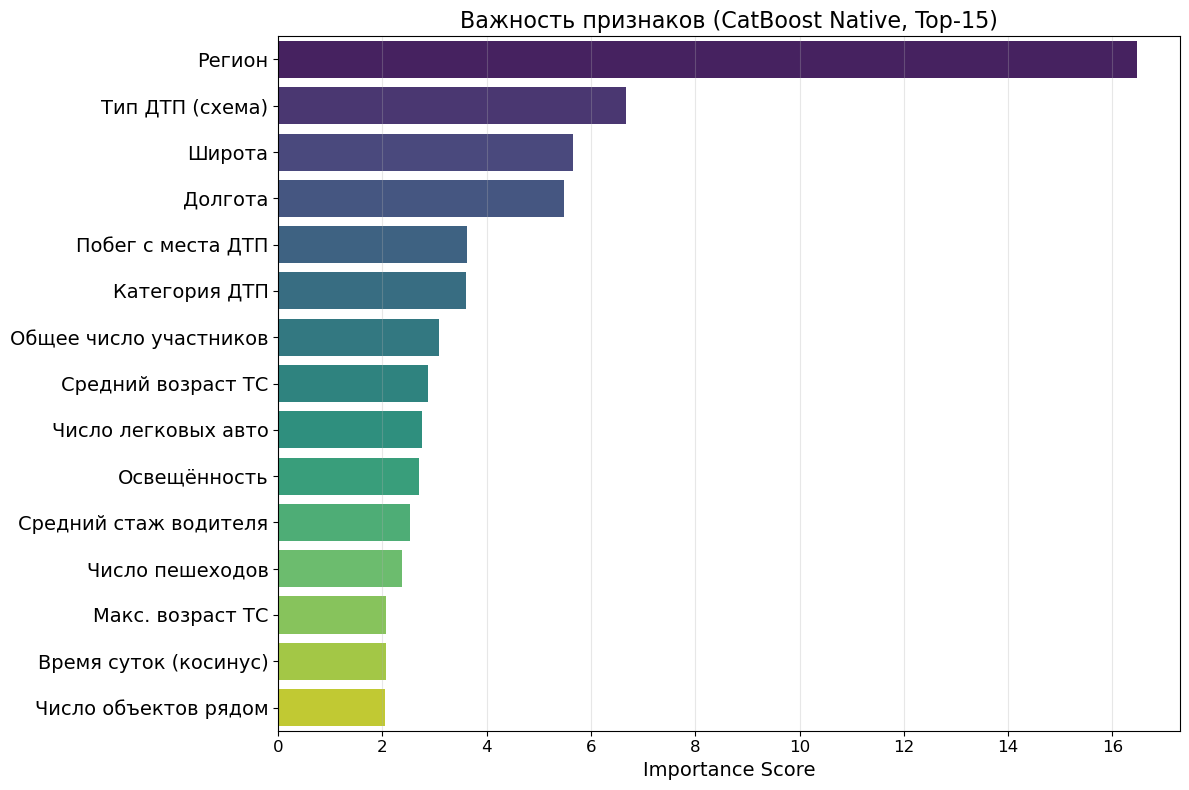

In [9]:
def plot_native_importance(model, X, mapping, save_path=None, top_n=15):
    """Строит столбчатую диаграмму важности признаков CatBoost."""
    feature_importance = model.get_feature_importance(type='FeatureImportance')
    feature_names = np.array(X.columns)
    
    sorted_idx = np.argsort(feature_importance)[::-1]
    
    top_features_eng = feature_names[sorted_idx[:top_n]]
    top_features_rus = [mapping.get(col, col) for col in top_features_eng]
    
    df_imp = pd.DataFrame({
        'Feature': top_features_rus,
        'Importance': feature_importance[sorted_idx[:top_n]]
    })
    
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=df_imp,
        x='Importance',
        y='Feature',
        hue='Feature',
        palette='viridis',
        legend=False
    )
    
    plt.title(f'Важность признаков (CatBoost Native, Top-{top_n})', fontsize=16)
    plt.xlabel('Importance Score', fontsize=14)
    plt.ylabel(None)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=14)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"График важности сохранен: {save_path}")
        
    plt.show()

reports_dir = exp_manager.get_paths(MODEL_NAME, stage=CURRENT_STAGE)['report']
plot_native_importance(model, X_train, feature_name_mapping, save_path=reports_dir / "native_importance.png")

### SHAP

SHAP график сохранен: D:\Education\Arcticle\dtp_project\res\01_dtp_stat\reports\03_catboost\catboost_binary_severe_4000\shap_summary_rus.png


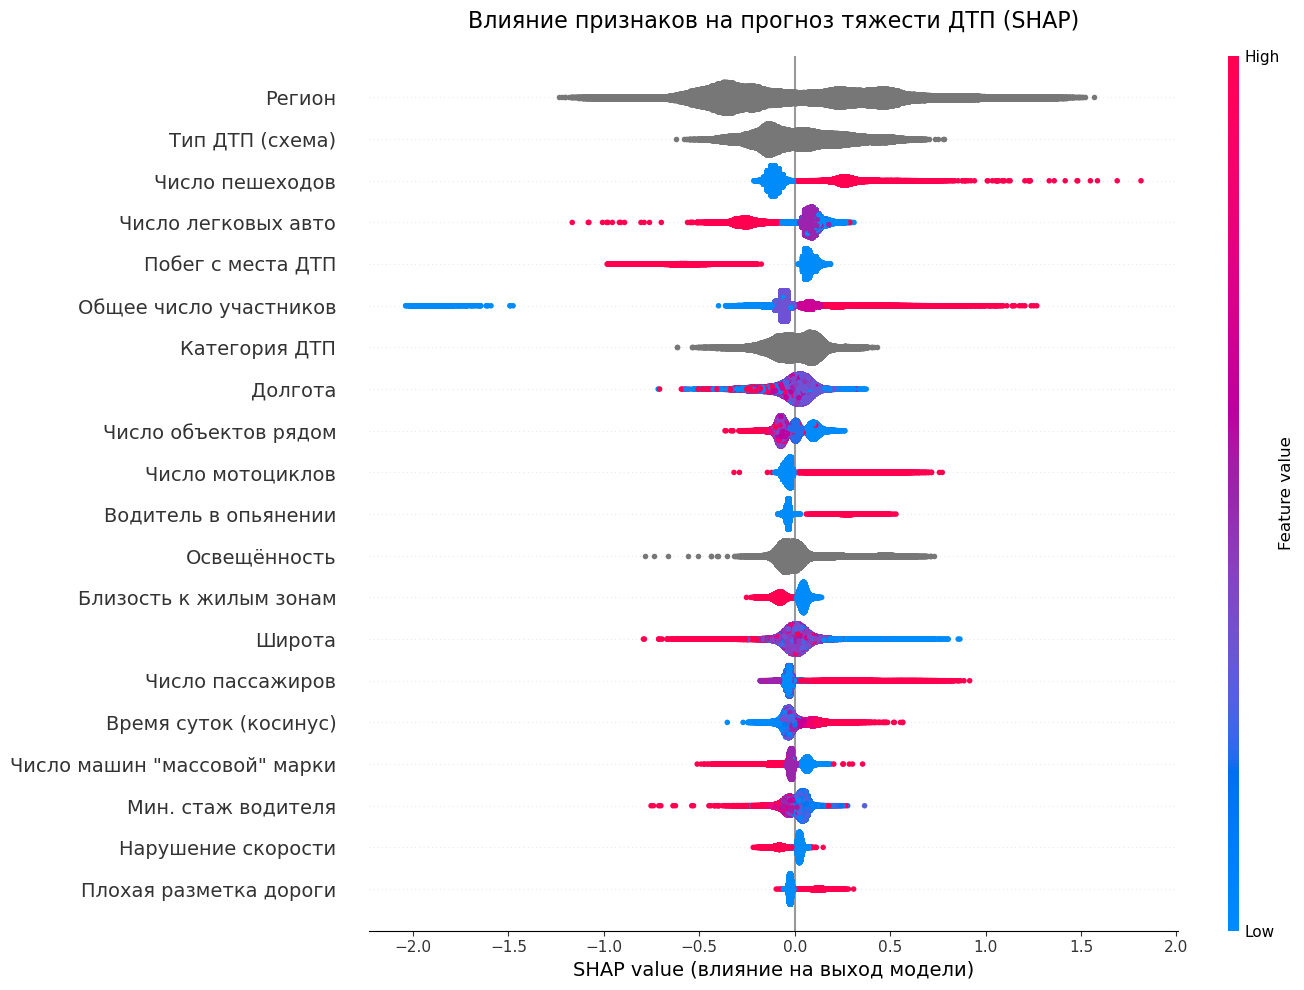

In [11]:
def plot_shap_summary(model, X, mapping, save_path=None, max_display=20):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    X_rus = X.copy()
    X_rus.columns = [mapping.get(col, col) for col in X.columns]

    plt.figure(figsize=(14, 10))
    plt.title("Влияние признаков на прогноз тяжести ДТП (SHAP)", fontsize=16, pad=20)
    
    shap.summary_plot(
        shap_values, 
        X_rus,  # Передаём данные с русскими именами только сюда
        max_display=max_display, 
        show=False,
        plot_size=None
    )
    
    plt.yticks(fontsize=14)
    plt.xlabel("SHAP value (влияние на выход модели)", fontsize=14)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"SHAP график сохранен: {save_path}")
        
    plt.show()

X_shap_sample = X_train # .sample(10000, random_state=42) if len(X_train) > 10000 else X_train

plot_shap_summary(
    model, 
    X_shap_sample, 
    feature_name_mapping, 
    save_path=reports_dir / "shap_summary_rus.png",
    max_display=20
)

#### Важности внутри групп


>>> Группа: WEATHER (Погода)


,Признак,Важность,Влияние,Corr
0,weather_clear,0.015705,↓ СНИЖАЕТ,-0.825
4,weather_rain,0.012360,↑ ПОВЫШАЕТ,0.952
3,weather_overcast,0.008385,↑ ПОВЫШАЕТ,0.503
5,weather_snow,0.003285,↑ ПОВЫШАЕТ,0.390
1,weather_fog,0.001536,↑ ПОВЫШАЕТ,0.921
7,weather_other,0.000649,↑ ПОВЫШАЕТ,0.875
2,weather_hot,0.000343,↑ ПОВЫШАЕТ,0.848
6,weather_wind,0.000171,↓ СНИЖАЕТ,-0.665


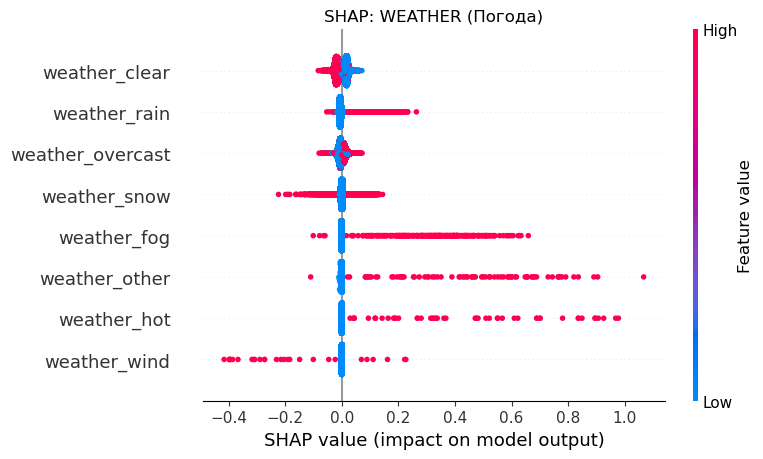


>>> Группа: ROAD (Дорожные условия)


,Признак,Важность,Влияние,Corr
4,road_bad_markings,0.038934,↑ ПОВЫШАЕТ,0.952
13,road_snow,0.030425,↓ СНИЖАЕТ,-0.966
5,road_bad_signs,0.024027,↑ ПОВЫШАЕТ,0.947
0,road_bad_fences,0.017792,↑ ПОВЫШАЕТ,0.957
8,road_dry,0.015248,↑ ПОВЫШАЕТ,0.837
6,road_bad_surface,0.014822,↑ ПОВЫШАЕТ,0.932
3,road_bad_maintenance,0.011540,↑ ПОВЫШАЕТ,0.888
10,road_no_light,0.009518,↑ ПОВЫШАЕТ,0.966
9,road_ice,0.009222,↓ СНИЖАЕТ,-0.854
14,road_wet,0.005846,↑ ПОВЫШАЕТ,0.086


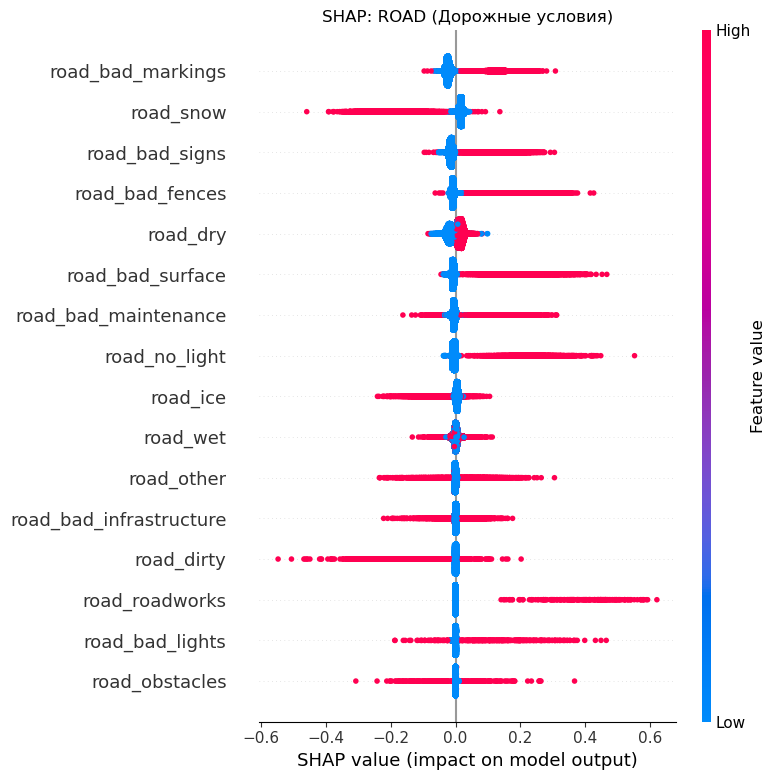


>>> Группа: VIOLATIONS (Нарушения)


,Признак,Важность,Влияние,Corr
6,viol_runaway,0.137361,↓ СНИЖАЕТ,-0.973
3,viol_drunk,0.063860,↑ ПОВЫШАЕТ,0.975
2,viol_speed,0.041125,↓ СНИЖАЕТ,-0.951
5,viol_rights,0.027466,↑ ПОВЫШАЕТ,0.950
0,viol_priority,0.016395,↑ ПОВЫШАЕТ,0.692
4,viol_safety,0.016325,↑ ПОВЫШАЕТ,0.932
1,viol_pedestrian,0.015612,↓ СНИЖАЕТ,-0.242
7,viol_admin,0.006919,↑ ПОВЫШАЕТ,0.183


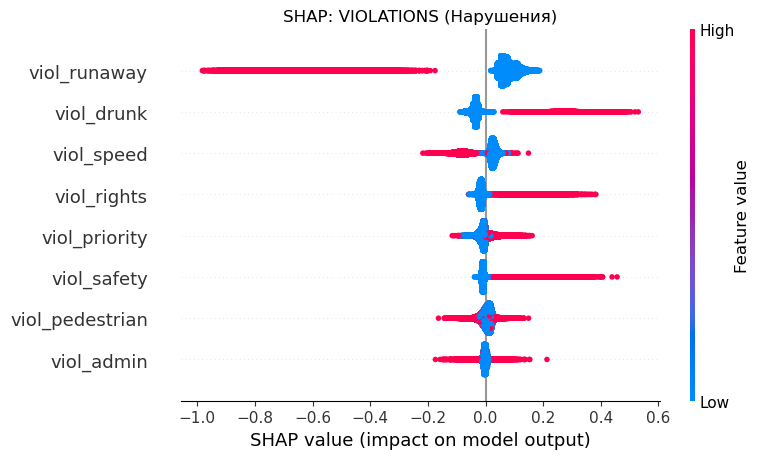


>>> Группа: VEHICLES (Характеристики ТС)


,Признак,Важность,Влияние,Corr
6,vh_count_car,0.144418,↓ СНИЖАЕТ,-0.856
9,vh_count_moto,0.067874,↑ ПОВЫШАЕТ,0.925
13,vh_count_brand_mass,0.051541,↓ СНИЖАЕТ,-0.937
5,vh_mean_age,0.037641,↑ ПОВЫШАЕТ,0.646
4,vh_max_age,0.029355,↑ ПОВЫШАЕТ,0.170
7,vh_count_truck,0.029104,↑ ПОВЫШАЕТ,0.920
3,vh_age_gap,0.023905,↑ ПОВЫШАЕТ,0.193
12,vh_count_brand_premium,0.010743,↑ ПОВЫШАЕТ,0.456
11,vh_count_brand_ru,0.007976,↑ ПОВЫШАЕТ,0.103
8,vh_count_bus,0.006299,↓ СНИЖАЕТ,-0.169


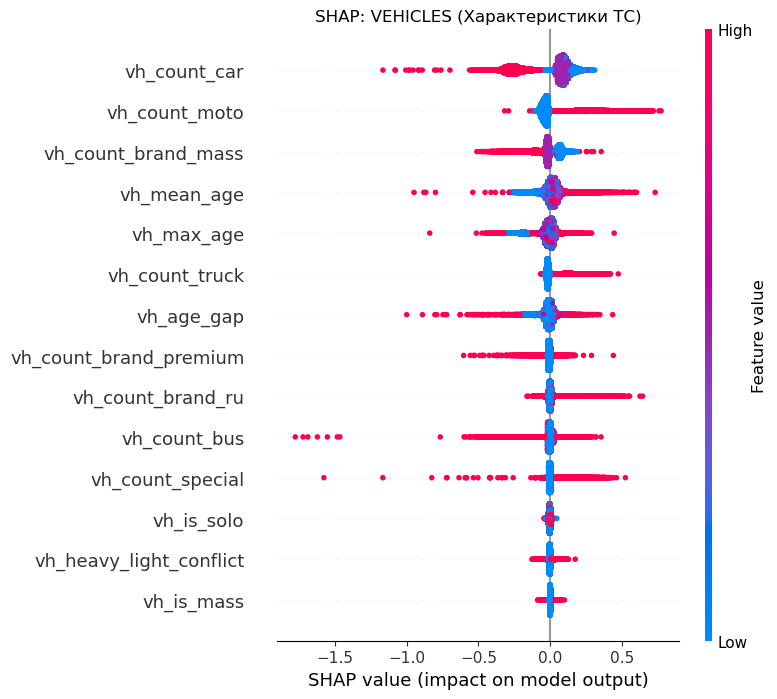


>>> Группа: INFRASTRUCTURE (Окружение)


,Признак,Важность,Влияние,Corr
7,nearby_objects_count,0.069490,↓ СНИЖАЕТ,-0.736
0,near_residential,0.060306,↓ СНИЖАЕТ,-0.937
5,near_public_transport,0.025243,↑ ПОВЫШАЕТ,0.875
2,near_road_junctions,0.018265,↓ СНИЖАЕТ,-0.907
4,near_commercial,0.011412,↓ СНИЖАЕТ,-0.825
1,near_pedestrian_infrastructure,0.009743,↑ ПОВЫШАЕТ,0.134
3,near_education,0.008298,↓ СНИЖАЕТ,-0.836
6,near_railway,0.000810,↓ СНИЖАЕТ,-0.170


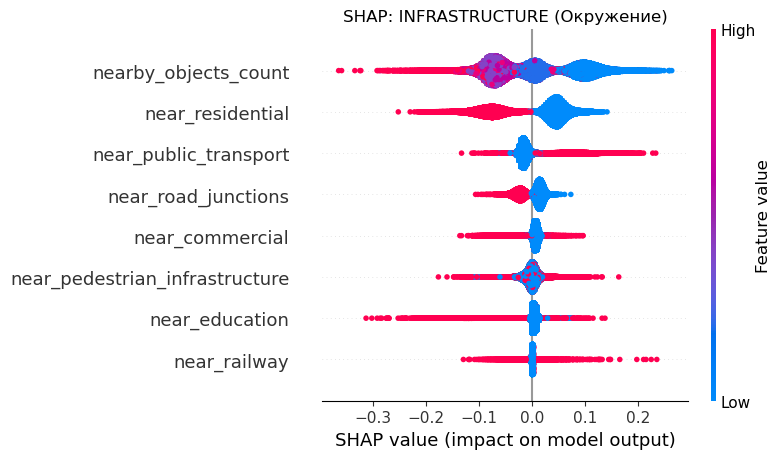

In [ ]:
from scipy.stats import pearsonr

# 1. Определяем списки колонок по группам (на основе твоего списка)
groups_dict = {
    "WEATHER (Погода)": [
        "weather_clear",
        "weather_fog",
        "weather_hot",
        "weather_overcast",
        "weather_rain",
        "weather_snow",
        "weather_wind",
        "weather_other",
    ],
    "ROAD (Дорожные условия)": [
        "road_bad_fences",
        "road_bad_infrastructure",
        "road_bad_lights",
        "road_bad_maintenance",
        "road_bad_markings",
        "road_bad_signs",
        "road_bad_surface",
        "road_dirty",
        "road_dry",
        "road_ice",
        "road_no_light",
        "road_obstacles",
        "road_roadworks",
        "road_snow",
        "road_wet",
        "road_other",
    ],
    "VIOLATIONS (Нарушения)": [
        "viol_priority",
        "viol_pedestrian",
        "viol_speed",
        "viol_drunk",
        "viol_safety",
        "viol_rights",
        "viol_runaway",
        "viol_admin",
    ],
    "VEHICLES (Характеристики ТС)": [
        "vh_is_solo",
        "vh_is_mass",
        "vh_heavy_light_conflict",
        "vh_age_gap",
        "vh_max_age",
        "vh_mean_age",
        "vh_count_car",
        "vh_count_truck",
        "vh_count_bus",
        "vh_count_moto",
        "vh_count_special",
        "vh_count_brand_ru",
        "vh_count_brand_premium",
        "vh_count_brand_mass",
    ],
    "INFRASTRUCTURE (Окружение)": [
        "near_residential",
        "near_pedestrian_infrastructure",
        "near_road_junctions",
        "near_education",
        "near_commercial",
        "near_public_transport",
        "near_railway",
        "nearby_objects_count",
    ],
}


def analyze_group_micro(group_name, cols, X_train, shap_values):
    """
    Анализирует признаки внутри конкретной группы.
    """
    # Фильтруем только существующие колонки
    valid_cols = [c for c in cols if c in X_train.columns]
    if not valid_cols:
        print(f"Группа {group_name} пуста или колонки не найдены.")
        return

    # Индексы колонок
    col_indices = [X_train.columns.get_loc(c) for c in valid_cols]

    # Срез данных и SHAP
    X_subset = X_train.iloc[:, col_indices]
    shap_subset = shap_values[:, col_indices]

    # Расчет метрик
    results = []
    for i, col in enumerate(valid_cols):
        vals = X_subset.iloc[:, i]
        shaps = shap_subset[:, i]

        importance = np.abs(shaps).mean()

        # Корреляция
        if vals.dtype == "object" or vals.dtype.name == "category":
            vals_num = vals.astype("category").cat.codes
        else:
            vals_num = vals

        if np.std(vals_num) == 0:
            corr = 0
        else:
            corr, _ = pearsonr(vals_num, shaps)

        direction = (
            "↑ ПОВЫШАЕТ"
            if corr > 0.05
            else ("↓ СНИЖАЕТ" if corr < -0.05 else "● Смешанно")
        )

        results.append(
            {
                "Признак": col,
                "Важность": importance,
                "Влияние": direction,
                "Corr": round(corr, 3),
            }
        )

    df_res = pd.DataFrame(results).sort_values(by="Важность", ascending=False)

    print(f"\n>>> Группа: {group_name}")
    display(df_res)

    # Рисуем микро-график
    plt.figure(figsize=(8, len(valid_cols) * 0.4 + 2))
    plt.title(f"SHAP: {group_name}")
    shap.summary_plot(shap_subset, X_subset, show=False, max_display=len(valid_cols))
    plt.show()


# --- ЗАПУСК ПО ВСЕМ ГРУППАМ ---
for name, cols in groups_dict.items():
    analyze_group_micro(name, cols, X_train, shap_values)